# Tourism Accomodation in Porto - a detailed analysis

In [ ]:
# 0. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from dash import Dash,dcc,html,Input,Output
import plotly.express as px
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


# Import dataset
porto = pd.read_csv("data/listings.csv")
neigh = pd.read_csv("data/neighbourhoods.csv")
porto = porto.copy()

## Data Inspection

In [ ]:
# 1. Data Inspection
porto.head(n=5)

In [ ]:
print(porto.info())
print(porto.describe())

## Data Filtering

In [ ]:
# Remove unnecessary columns
cols_to_drop = ["name", "host_id", "host_name", "reviews_per_month", "last_review", "number_of_reviews_ltm", "license"]
porto_df = porto.drop(columns=cols_to_drop, inplace=False)
porto_df.head(n=5)

In [ ]:
## Remove unavailable listings
porto_df = porto_df[porto_df["availability_365"] > 0]

In [ ]:
## Minimum_nights - outlier detection
plt.figure()
plt.boxplot(porto_df[porto_df["minimum_nights"] <= 50]["minimum_nights"], vert=False)
plt.xlabel("Minimum Nights")
plt.title("Minimum Nights (50 days or less) - outlier detection")
plt.show()

In [ ]:
# Removing minimum_nights outliers
porto_df = porto_df[porto_df["minimum_nights"] <= 3]

# 3rd quantile = 2 days so limit is set to 3 days

In [ ]:
# Price - outlier detection
plt.figure()
plt.boxplot(porto_df[porto_df["price"] <= 2000]["price"], vert=False)
plt.xlabel("Price")
plt.title("Price - outlier detection")
plt.show()

In [ ]:
# Price filtering
porto_df = porto_df[porto_df["price"] <= 500]


In [ ]:
# Remove price NaN values
porto_df = porto_df.dropna(subset=["price"])

In [ ]:
# Check final dataset
porto_df.info()

# Obs: filtered dataset has no null values

## Data Transformation

In [ ]:
# Feature engineering

## Minimum nights * price = total minimum cost to stay
porto_df["total_min_cost"] = porto_df["minimum_nights"] * porto_df["price"]

## Exploratory Data Analysis

In [ ]:
# price and total_min_cost distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(porto_df["price"], bins=50, kde=True, ax=axes[0])
axes[0].set_xlabel("Price")
axes[0].set_title("Price Distribution")

sns.histplot(porto_df["total_min_cost"], bins=50, kde=True, ax=axes[1])
axes[1].set_xlabel("Total Minimum Cost")
axes[1].set_title("Total Minimum Cost Distribution")

plt.tight_layout()
plt.show()


In [ ]:
# number of listings by neighbourhood group + room type
counts = porto_df.groupby("neighbourhood_group").size().reset_index(name="count")
counts = counts.sort_values(by="count", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(data=counts, y="neighbourhood_group", x="count", order=counts["neighbourhood_group"], ax = axes[0])
axes[0].set_xlabel("Nr. of listings")
axes[0].set_ylabel("Neighbourhood Group")
axes[0].set_title("Listings per Neighbourhood Group")


# number of listings by room type
counts_room = porto_df.groupby("room_type").size().reset_index(name="count")
counts_room = counts_room.sort_values(by="count", ascending=False)
sns.barplot(data=counts_room, y="room_type", x="count", order=counts_room["room_type"], ax = axes[1])
axes[1].set_xlabel("Nr. of listings")
axes[1].set_ylabel("Room Type")
axes[1].set_title("Listings per Room Type")

plt.tight_layout()
plt.subplots_adjust(wspace=0.38)   
plt.show()


In [ ]:
prt2 = gpd.read_file("data/PRT_2.shp")
mun = gpd.read_file("data/portugal_municipios.geojson")

# subset where name_1 == 'Porto'
porto_geo = mun[mun["name_1"] == "Porto"]

In [ ]:
app=Dash(__name__)

porto_df["price"]=porto_df["price"].astype(float)
geojson=porto_geo.to_json()

controls=html.Div(style={"position":"absolute","top":"20px","left":"20px","zIndex":999,
                         "backgroundColor":"black","padding":"15px",
                         "borderRadius":"10px","color":"white","fontFamily":"Verdana","display":"flex",
                         "flexDirection":"column","gap":"14px"},children=[
html.H4("Porto Airbnb Dashboard"),

html.Label("Color Variable"),
dcc.RadioItems(id="color_var",options=[{"label":"Availability","value":"availability_365"},{"label":"Price","value":"price"}],value="availability_365",inline=True),

html.Label("Room Type"),
dcc.Dropdown(id="room",options=[{"label":i,"value":i} for i in porto_df["room_type"].unique()],multi=True, style={"color":"black","backgroundColor":"white"}),

html.Label("Neighbourhood Group"),
dcc.Dropdown(id="neigh",options=[{"label":i,"value":i} for i in porto_df["neighbourhood_group"].unique()],multi=True, style={"color":"black","backgroundColor":"white"})])

app.layout=html.Div(style={"backgroundColor":"black"},children=[controls,dcc.Graph(id="map",style={"height":"100vh"})])
@app.callback(Output("map","figure"),Input("room","value"),Input("neigh","value"),Input("color_var","value"))

def update_map(room,neigh,color_var):
    df=porto_df.copy()
    if room: df=df[df["room_type"].isin(room)]
    if neigh: df=df[df["neighbourhood_group"].isin(neigh)]

    fig=px.scatter_map(df,lat="latitude",lon="longitude",color=color_var,zoom=11, color_continuous_scale="Plasma",map_style="carto-darkmatter")

    fig.update_layout(paper_bgcolor="black",plot_bgcolor="black", font=dict(family="Verdana",color="white"), coloraxis_colorbar=dict(title=color_var), 
                      mapbox_layers=[{"source":geojson,"type":"line","color":"cyan","line":{"width":1}}], margin=dict(r=0,t=0,l=0,b=0))
    return fig

app.run(debug=True)


In [ ]:
# Classification - professional hosts vs casual hosts

# Feature engineering - professional host
porto_df["professional_host"] = (porto_df["calculated_host_listings_count"] > 3)


In [ ]:
# Professional hosts vs casual hosts - price and total minimum cost distribution

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price
axes[0].violinplot([porto_df[porto_df["professional_host"]]["price"], porto_df[~porto_df["professional_host"]]["price"]], showmedians=True)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Professional Hosts", "Particular Hosts"])
axes[0].set_ylabel("Price")
axes[0].set_xlabel("Professional Host Status")
axes[0].set_title("Price Distribution by Host Type")

# Total Minimum Cost
sns.histplot(data=porto_df, x="minimum_nights", hue="professional_host", multiple="dodge", palette=["#4555ae","#d67476"], bins=10, alpha=0.6, ax=axes[1])
axes[1].set_xlabel("Minimum Nights")
axes[1].set_ylabel("Count")
axes[1].set_title("Minimum Nights by Host Type")
axes[1].legend(title="Host Type", loc="upper right", labels=["Professional Hosts", "Particular Hosts"])
axes[1].set_xlim(0, 4)  # optional to focus on realistic range

plt.tight_layout()
plt.subplots_adjust(wspace=0.18)   
plt.show()


In [ ]:
# Region Clustering by Price

# Prepare the data
porto_df["neigh"] = porto_df["neighbourhood_group"].map({'PORTO': 'POR', 'ESPINHO': 'ESP', 'VILA NOVA DE GAIA': 'VNG', 'MATOSINHOS': 'MAT', 'GONDOMAR': 'GON',
       'VILA DO CONDE': 'VDC', 'MAIA': 'MAI', 'PAREDES': 'PAR', 'AROUCA': 'ARO', 'SANTA MARIA DA FEIRA': 'SMF', 'VALE DE CAMBRA': 'VAC', 'PÓVOA DE VARZIM': 'POV',
       'OLIVEIRA DE AZEMÉIS': 'OLA', 'TROFA': 'TRO', 'VALONGO': 'VAL', 'SANTO TIRSO': 'STI', 'SÃO JOÃO DA MADEIRA': 'SJDM'})

region_stats = porto_df.groupby("neigh")["price"].agg(["mean","median","std","count"]).reset_index()
features = region_stats[["mean","median","std","count"]]
X = StandardScaler().fit_transform(features)

# Elbow method for KMeans
inertia = []
for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)
plt.figure(figsize=(6,4))
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.show()

In [ ]:
# KMeans with chosen k (replace 3 with your optimal k from elbow)
kmeans = KMeans(n_clusters=6, random_state=42)
region_stats["kmeans_cluster"] = kmeans.fit_predict(X)

# DBSCAN clustering
dbscan = DBSCAN(eps=1.5, min_samples=3)  # eps can be tuned
region_stats["dbscan_cluster"] = dbscan.fit_predict(X)

# Plot KMeans clusters
"""
plt.figure(figsize=(6,4))
sns.scatterplot(data=region_stats, x="mean", y="median", hue="kmeans_cluster", s=100, palette="Set2")
for i,row in region_stats.iterrows(): plt.text(row["mean"]+0.5,row["median"],row["neighbourhood_group"])
plt.xlabel("Mean Price")
plt.ylabel("Median Price")
plt.title("KMeans Clustering by Price")
plt.show()
"""

# Plot DBSCAN clusters
plt.figure(figsize=(12,7))
sns.scatterplot(data=region_stats, x="mean", y="median", hue="dbscan_cluster", s=100, palette="Set1")
for i,row in region_stats.iterrows(): plt.text(row["mean"]+0.5,row["median"],row["neigh"])
plt.xlabel("Mean Price")
plt.ylabel("Median Price")
plt.title("DBSCAN Clustering by Price")
plt.show()

# print(region_stats[["neighbourhood_group","mean","median","kmeans_cluster","dbscan_cluster"]])


In [ ]:
porto_df['price_log'] = np.log1p(porto_df['price'])
porto_df['professional_host'] = porto_df['professional_host'].astype(int)

# one-hot encode room_type
porto_df = pd.get_dummies(porto_df, columns=['room_type'], drop_first=True)
features = ['price_log','number_of_reviews', 'availability_365', 'minimum_nights', 'calculated_host_listings_count', 'professional_host']

X = porto_df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN
db = DBSCAN(eps=0.7, min_samples=30)
porto_df['cluster'] = db.fit_predict(X_scaled)


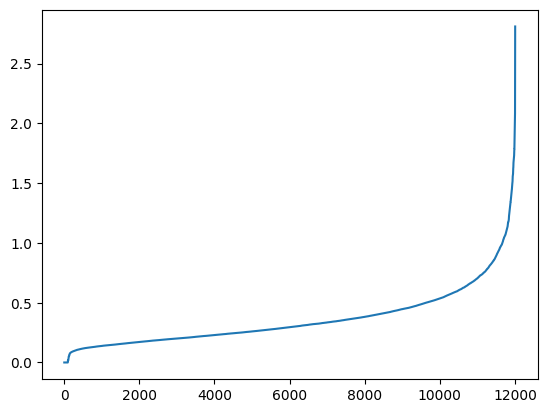

In [197]:
neighbors = NearestNeighbors(n_neighbors=30)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,29])
plt.plot(distances);

In [212]:
# DBSCAN
db = DBSCAN(eps=1.4, min_samples=30)
porto_df['cluster'] = db.fit_predict(X_scaled)

porto_df.groupby('cluster')[features + ['price']].median()
porto_df['cluster'].value_counts()

cluster
 5    3472
 3    2884
 0    2187
 4    1329
 2     982
 1     724
 6     286
-1      90
 7      53
Name: count, dtype: int64

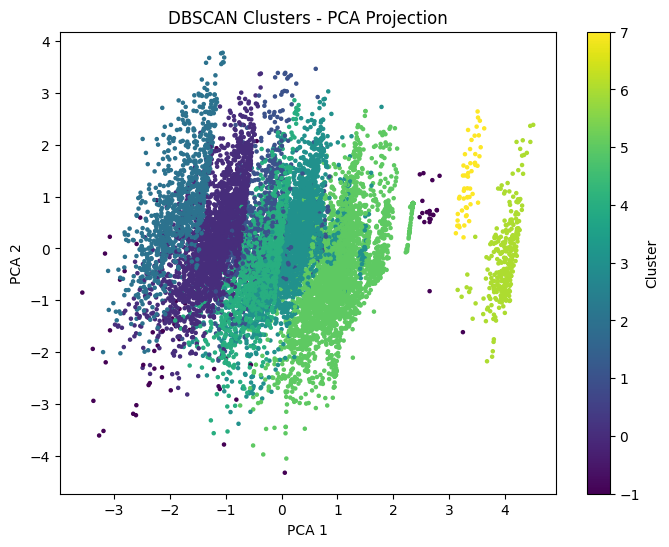

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

# Separate noise points (-1) from clusters
noise_mask = porto_df['cluster'] == -1
cluster_mask = porto_df['cluster'] != -1

# Plot clusters
scatter1 = plt.scatter(
    X_pca[cluster_mask, 0],
    X_pca[cluster_mask, 1],
    c=porto_df[cluster_mask]['cluster'],
    s=10,
    cmap='tab10',
    alpha=0.6,
    label='Clusters'
)

# Plot noise points in a distinct color
scatter2 = plt.scatter(
    X_pca[noise_mask, 0],
    X_pca[noise_mask, 1],
    c='red',
    s=10,
    marker='x',
    alpha=0.8,
    label='Noise (-1)'
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('DBSCAN Clusters - PCA Projection')
plt.legend()
plt.colorbar(label='Cluster')

plt.tight_layout()
plt.show()


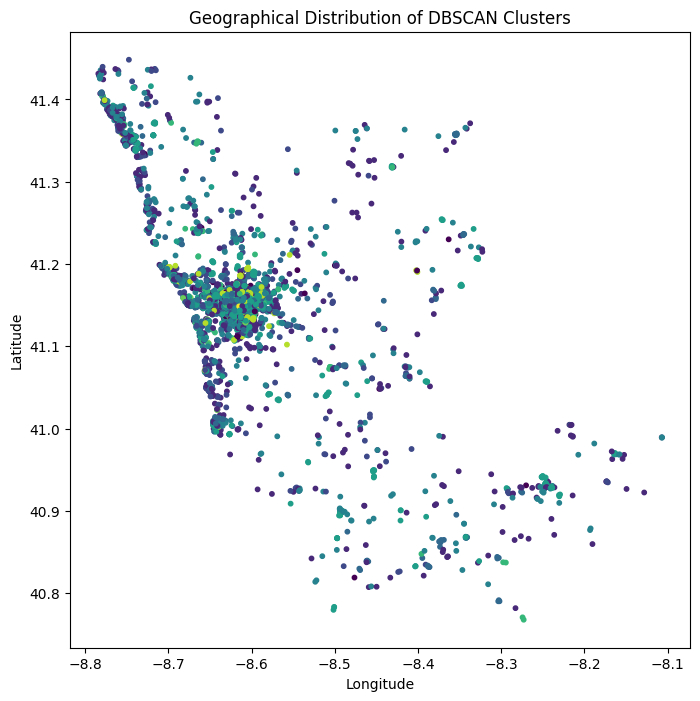

In [202]:
plt.figure(figsize=(8,8))

plt.scatter(
    porto_df['longitude'],
    porto_df['latitude'],
    c=porto_df['cluster'],
    s=10
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of DBSCAN Clusters')

plt.show()

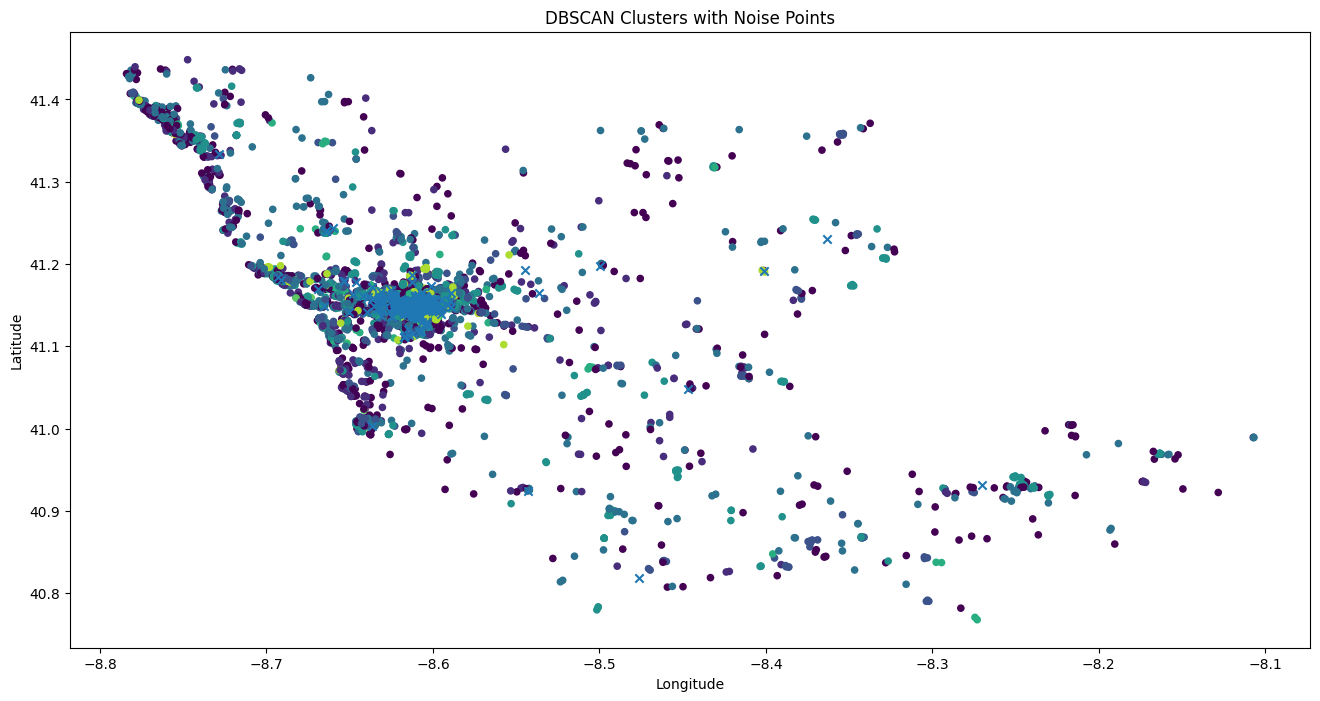

In [207]:
plt.figure(figsize=(16,8))

# clusters
plt.scatter(
    porto_df[porto_df['cluster'] != -1]['longitude'],
    porto_df[porto_df['cluster'] != -1]['latitude'],
    c=porto_df[porto_df['cluster'] != -1]['cluster'],
    s=20
)

# noise
plt.scatter(
    porto_df[porto_df['cluster'] == -1]['longitude'],
    porto_df[porto_df['cluster'] == -1]['latitude'],
    marker='x'
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('DBSCAN Clusters with Noise Points')

plt.show()


Workflow:
- Data Inspection
    - .head - check which columns can be removed
    - .info and .describe - check for NaNs and anomalous values

- Data Filtering
    - remove useless columns
    - remove anomalies
        - availability = 0
        - minimum_nights very high
    - deal with NaN
        - remove price NaNs

- EDA

- Modelling



Analytical Goals:

- EDA
    - mean price and mean minimum total price (price/minimum nights)
    - n listings by neighbourhood group
    - n listings by room type
    - pro/particular host classification
    - map with availability color
- Modelling/ML:
    - unsupervised classification of regions by price?
    - create new variable - proximity to subway station - and model price with random forest of other algorithm
    
